<a href="https://colab.research.google.com/github/reshmajayaghosh/ICT/blob/main/Intermediate_Assessment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **`Training Dataset`**

# `Step 1 : Problem Statement`

In [907]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [908]:
train_df = pd.read_csv("/content/drive/MyDrive/ICT DSA Python/Data/train_ctrUa4K.csv")
train_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


**Target Column**

       Loan_Status

In [909]:
train_df['Loan_Status'].value_counts()

,count
Loan_Status,
Y,422
N,192


In [910]:
train_df.shape

(614, 13)

In [911]:
train_df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


# `Step 2 : Pre - Processing`

In [912]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [913]:
train_df['Loan_ID'].nunique()

614

**Droping the column**

Droping the column - ID as it a unique value - so dropping that column

In [914]:
train_df.drop(columns = ['Loan_ID'], inplace = True)

In [915]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             601 non-null    object 
 1   Married            611 non-null    object 
 2   Dependents         599 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      582 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         592 non-null    float64
 8   Loan_Amount_Term   600 non-null    float64
 9   Credit_History     564 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 57.7+ KB


# 1. Checking Duplicates

In [916]:
train_df.duplicated().sum()

np.int64(0)

# 2. Checking Missing Values

In [917]:
train_df.isna().sum()

,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14
Credit_History,50


In [918]:
round(train_df.isna().mean()*100,2)

,0
Gender,2.12
Married,0.49
Dependents,2.44
Education,0.00
Self_Employed,5.21
ApplicantIncome,0.00
CoapplicantIncome,0.00
LoanAmount,3.58
Loan_Amount_Term,2.28
Credit_History,8.14


In [919]:
numerical_cols_train = train_df.select_dtypes(include = "number").columns
train_df[numerical_cols_train].columns

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')

In [920]:
cat_cols_train = train_df.select_dtypes(exclude = "number").columns
train_df[cat_cols_train].columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area', 'Loan_Status'],
      dtype='object')

<Axes: >

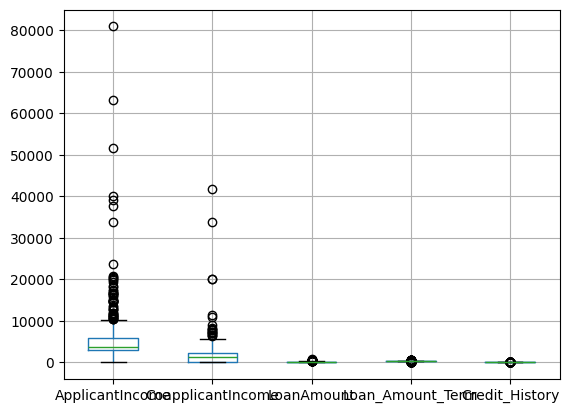

In [921]:
train_df[numerical_cols_train].boxplot()

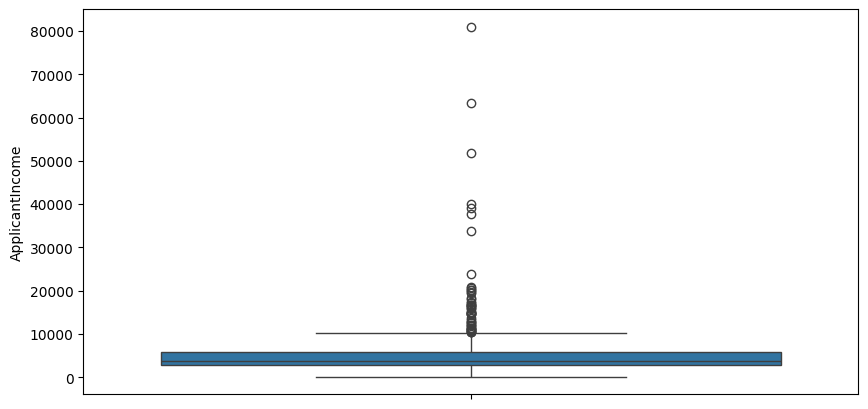

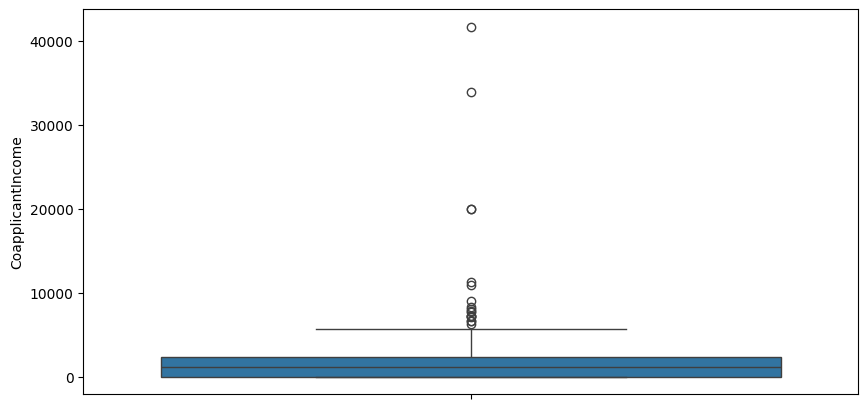

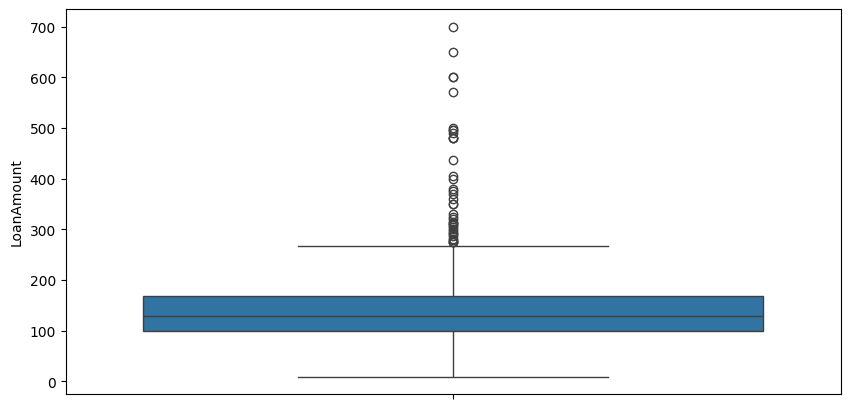

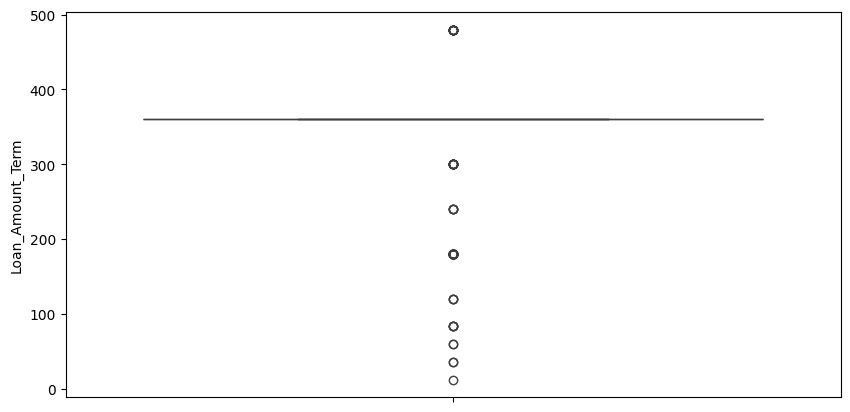

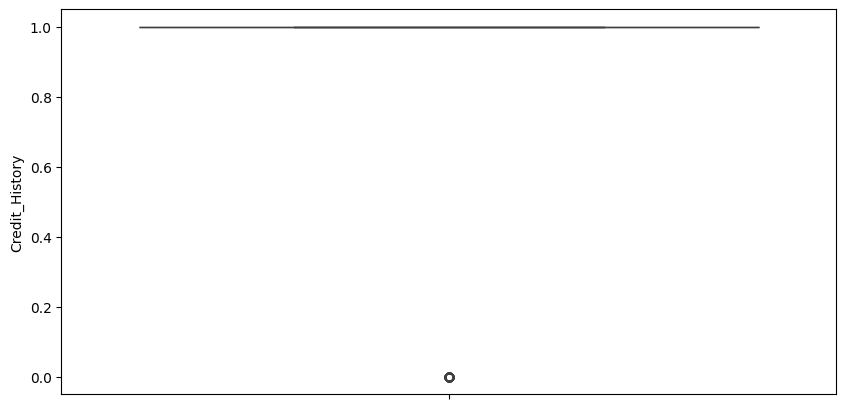

In [922]:
for i in train_df[numerical_cols_train].columns:
  plt.figure(figsize = (10,5))
  sns.boxplot(train_df[i])
  plt.show()

*Using SimpleImputer replaced by median*

In [923]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy = 'median')
train_df[numerical_cols_train] = imputer.fit_transform(train_df[numerical_cols_train])

*Using SimpleImputer replaced by mode*

In [924]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy = 'most_frequent')
train_df[cat_cols_train] = imputer.fit_transform(train_df[cat_cols_train])

In [925]:
train_df.isna().sum()

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


# 3. Outlier Detection and Handling

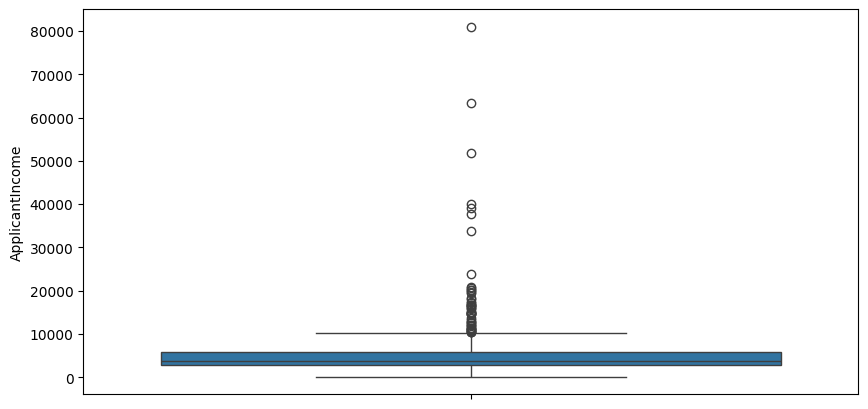

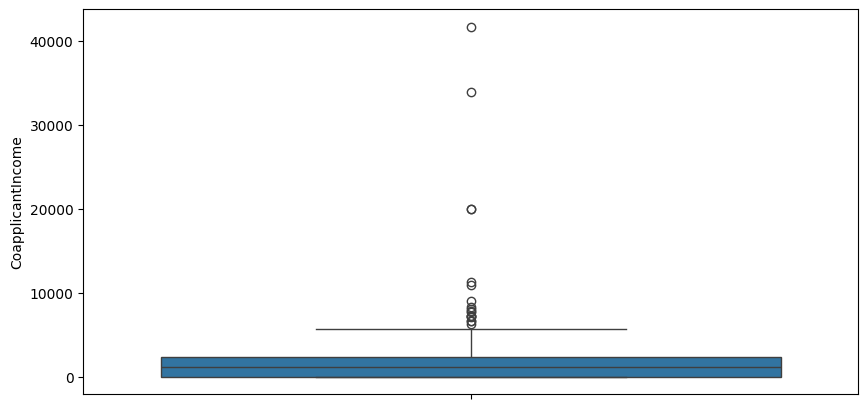

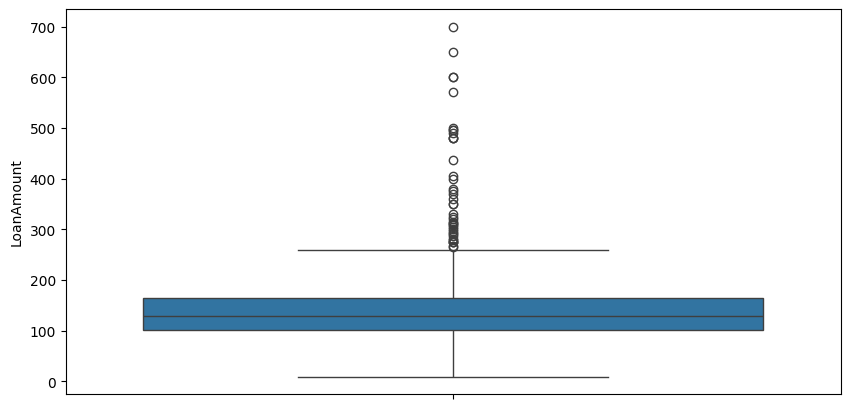

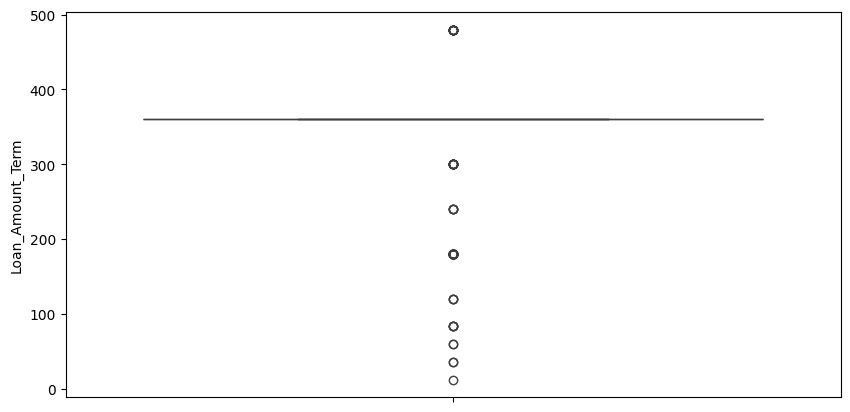

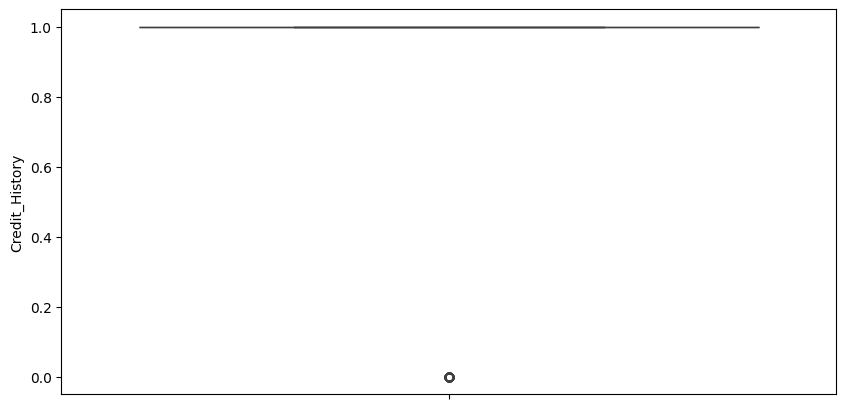

In [926]:
for i in train_df[numerical_cols_train].columns:
  plt.figure(figsize = (10,5))
  sns.boxplot(train_df[i])
  plt.show()

*Removing all the outliers from the numerical columns*

In [927]:
train_df[numerical_cols_train].columns

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')

In [928]:
def handle_outliers(df, columns):
  for i in columns:
    if df[i].dtype in ['int64', 'float64']:
      q1 = df[i].quantile(0.25)
      q3 = df[i].quantile(0.75)
      iqr = q3 - q1
      lower_bound = q1 - 1.5 * iqr
      upper_bound = q3 + 1.5 * iqr
      df[i] = df[i].clip(lower_bound,upper_bound)

  return df


In [929]:
train_df[numerical_cols_train] = handle_outliers(train_df[numerical_cols_train], train_df[numerical_cols_train].columns)

/tmp/ipython-input-5299859.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[i] = df[i].clip(lower_bound,upper_bound)
/tmp/ipython-input-5299859.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[i] = df[i].clip(lower_bound,upper_bound)
/tmp/ipython-input-5299859.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/u

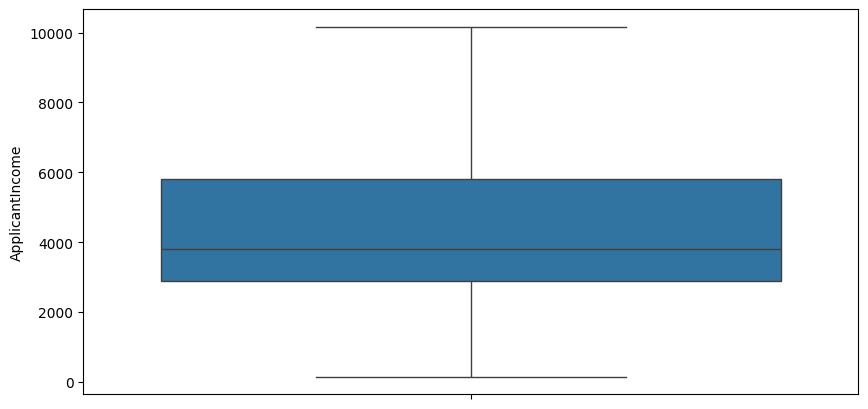

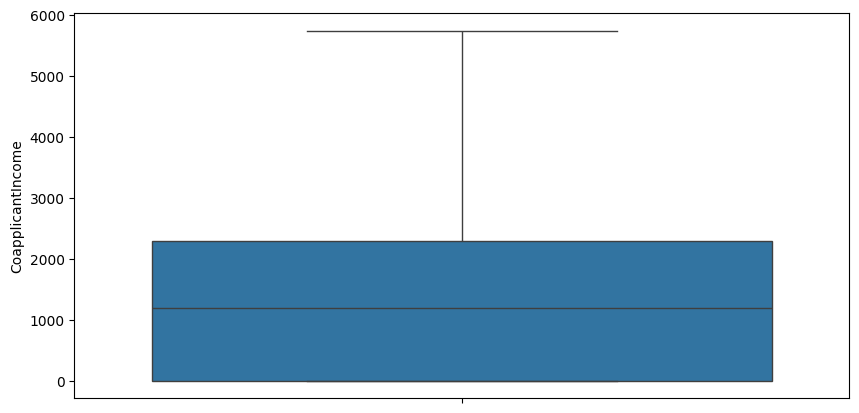

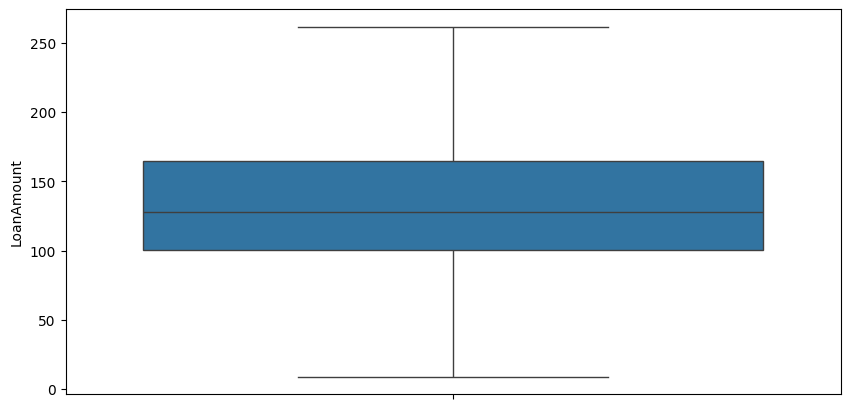

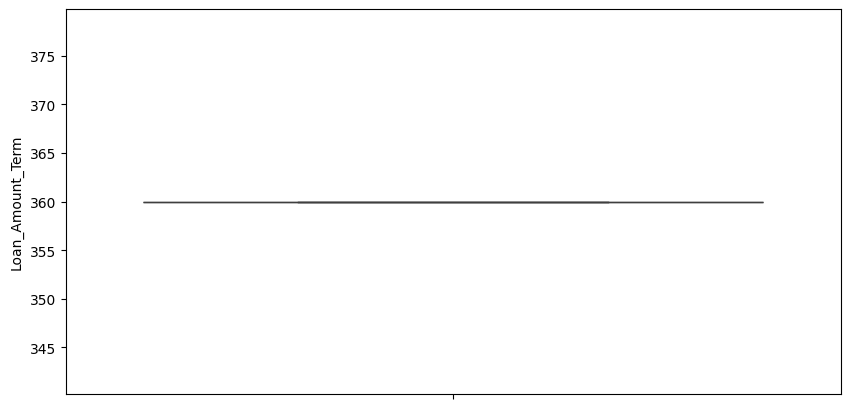

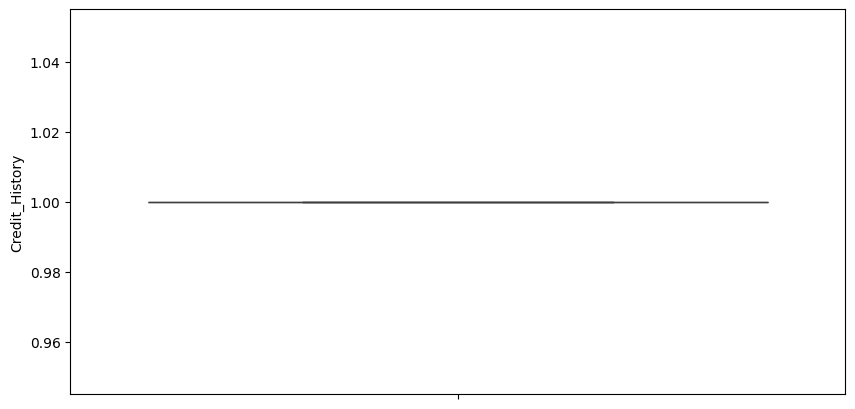

In [930]:
for i in train_df[numerical_cols_train].columns:
  plt.figure(figsize = (10,5))
  sns.boxplot(train_df[i])
  plt.show()

# 4. Feature Selection

In [931]:
train_df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849.0,0.0,128.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583.0,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000.0,0.0,141.0,360.0,1.0,Urban,Y


In [932]:
train_df['Credit_History'].value_counts()

,count
Credit_History,
1.0,614


In [933]:
train_df['Loan_Amount_Term'].value_counts()

,count
Loan_Amount_Term,
360.0,614


In [934]:
train_df.drop(columns = ['Loan_Amount_Term'], inplace = True)

In [935]:
train_df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849.0,0.0,128.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583.0,1508.0,128.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000.0,0.0,141.0,1.0,Urban,Y


# 5. Handling Skewness

In [936]:
train_df.select_dtypes('number').skew()

,0
ApplicantIncome,1.039846
CoapplicantIncome,1.012763
LoanAmount,0.683693
Credit_History,0.000000


*Handling all the columns that have skewness*

In [937]:
train_df['ApplicantIncome']= np.sqrt(train_df['ApplicantIncome'])
train_df['CoapplicantIncome'] = np.sqrt(train_df['CoapplicantIncome'])
train_df['LoanAmount'] = np.cbrt(train_df['LoanAmount'])

In [938]:
train_df.select_dtypes('number').skew()

,0
ApplicantIncome,0.540741
CoapplicantIncome,0.192830
LoanAmount,-0.208445
Credit_History,0.000000


In [939]:
train_df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,76.478755,0.000000,5.039684,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,67.697858,38.832976,5.039684,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,54.772256,0.000000,4.041240,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,50.823223,48.559242,4.932424,1.0,Urban,Y
4,Male,No,0,Graduate,No,77.459667,0.000000,5.204828,1.0,Urban,Y


# 6. Encoding

In [940]:
cat_cols_train = train_df.select_dtypes('object').columns
cat_cols_train

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area', 'Loan_Status'],
      dtype='object')

In [941]:
train_df['Gender'].value_counts()

,count
Gender,
Male,502
Female,112


In [942]:
train_df['Married'].value_counts()

,count
Married,
Yes,401
No,213


In [943]:
train_df['Dependents'].value_counts()

,count
Dependents,
0,360
1,102
2,101
3+,51


In [944]:
train_df['Education'].value_counts()

,count
Education,
Graduate,480
Not Graduate,134


In [945]:
train_df['Self_Employed'].value_counts()

,count
Self_Employed,
No,532
Yes,82


In [946]:
train_df['Property_Area'].value_counts()

,count
Property_Area,
Semiurban,233
Urban,202
Rural,179


In [947]:
train_df['Loan_Status'].value_counts()

,count
Loan_Status,
Y,422
N,192


**Label Encoding**

In [948]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train_df['Gender'] = le.fit_transform(train_df['Gender'])
train_df['Married'] = le.fit_transform(train_df['Married'])
train_df['Education'] = le.fit_transform(train_df['Education'])
train_df['Self_Employed'] = le.fit_transform(train_df['Self_Employed'])
train_df['Loan_Status'] = le.fit_transform(train_df['Loan_Status'])

**OneHot Encoding**

In [949]:
train_df = pd.get_dummies(train_df, columns = ['Dependents', 'Property_Area'],dtype = int, drop_first=True)

In [950]:
train_df.head()

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Credit_History,Loan_Status,Dependents_1,Dependents_2,Dependents_3+,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,0,76.478755,0.000000,5.039684,1.0,1,0,0,0,0,1
1,1,1,0,0,67.697858,38.832976,5.039684,1.0,0,1,0,0,0,0
2,1,1,0,1,54.772256,0.000000,4.041240,1.0,1,0,0,0,0,1
3,1,1,1,0,50.823223,48.559242,4.932424,1.0,1,0,0,0,0,1
4,1,0,0,0,77.459667,0.000000,5.204828,1.0,1,0,0,0,0,1


# 7. Correlataion

In [951]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif= pd.DataFrame()
vif['VIF']=[variance_inflation_factor(train_df.values,i) for i in range(train_df.shape[1])]
vif['Columns']=train_df.columns
vif.sort_values('VIF',ascending = False)

,VIF,Columns
7,65.119994,Credit_History
4,1.989337,ApplicantIncome
6,1.777101,LoanAmount
5,1.609325,CoapplicantIncome
12,1.492800,Property_Area_Semiurban
13,1.476844,Property_Area_Urban
1,1.395063,Married
0,1.223010,Gender
10,1.205466,Dependents_2
9,1.153677,Dependents_1


In [952]:
train_df['LoanAmount'].value_counts()

,count
LoanAmount,
6.394755,41
5.039684,33
4.932424,20
4.791420,17
4.641589,15
...,...
3.301927,1
3.936497,1
5.265637,1


In [953]:
# df.drop(columns = ['LoanAmount'], inplace = True)

In [954]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif= pd.DataFrame()
vif['VIF']=[variance_inflation_factor(train_df.values,i) for i in range(train_df.shape[1])]
vif['Columns']=train_df.columns
vif.sort_values('VIF',ascending = False)

,VIF,Columns
7,65.119994,Credit_History
4,1.989337,ApplicantIncome
6,1.777101,LoanAmount
5,1.609325,CoapplicantIncome
12,1.492800,Property_Area_Semiurban
13,1.476844,Property_Area_Urban
1,1.395063,Married
0,1.223010,Gender
10,1.205466,Dependents_2
9,1.153677,Dependents_1


In [955]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   614 non-null    int64  
 1   Married                  614 non-null    int64  
 2   Education                614 non-null    int64  
 3   Self_Employed            614 non-null    int64  
 4   ApplicantIncome          614 non-null    float64
 5   CoapplicantIncome        614 non-null    float64
 6   LoanAmount               614 non-null    float64
 7   Credit_History           614 non-null    float64
 8   Loan_Status              614 non-null    int64  
 9   Dependents_1             614 non-null    int64  
 10  Dependents_2             614 non-null    int64  
 11  Dependents_3+            614 non-null    int64  
 12  Property_Area_Semiurban  614 non-null    int64  
 13  Property_Area_Urban      614 non-null    int64  
dtypes: float64(4), int64(10)
m

# 8. Scaling and Normalization

In [956]:
train_df.head()

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Credit_History,Loan_Status,Dependents_1,Dependents_2,Dependents_3+,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,0,76.478755,0.000000,5.039684,1.0,1,0,0,0,0,1
1,1,1,0,0,67.697858,38.832976,5.039684,1.0,0,1,0,0,0,0
2,1,1,0,1,54.772256,0.000000,4.041240,1.0,1,0,0,0,0,1
3,1,1,1,0,50.823223,48.559242,4.932424,1.0,1,0,0,0,0,1
4,1,0,0,0,77.459667,0.000000,5.204828,1.0,1,0,0,0,0,1


In [957]:
scaling_cols_train = [
    'ApplicantIncome',
    'CoapplicantIncome',
    'LoanAmount'
    ]

In [958]:
from sklearn.preprocessing import MinMaxScaler

scaler_train = MinMaxScaler()
train_df[scaling_cols_train] = scaler_train.fit_transform(train_df[scaling_cols_train])

In [959]:
train_df.head()

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Credit_History,Loan_Status,Dependents_1,Dependents_2,Dependents_3+,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,0,0.724916,0.000000,0.685939,1.0,1,0,0,0,0,1
1,1,1,0,0,0.625815,0.512421,0.685939,1.0,0,1,0,0,0,0
2,1,1,0,1,0.479936,0.000000,0.454532,1.0,1,0,0,0,0,1
3,1,1,1,0,0.435367,0.640764,0.661079,1.0,1,0,0,0,0,1
4,1,0,0,0,0.735987,0.000000,0.724214,1.0,1,0,0,0,0,1


# `Step 3 : Model Training, Evaluationa and Selection`

# Data Splitting

In [960]:
x = train_df.drop(columns = 'Loan_Status')
y = train_df['Loan_Status']

In [961]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [962]:
x_train.shape

(491, 13)

In [963]:
y_test.shape

(123,)

# Training the model

In [964]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [965]:
model = [
    KNeighborsClassifier(),
    SVC(),
    LogisticRegression(),
    DecisionTreeClassifier(),
    RandomForestClassifier(),
    GaussianNB()
]

for i in model:
  i.fit(x_train,y_train)
  y_pred = i.predict(x_test)
  print(i)
  print('******************************************************')
  print(accuracy_score(y_test,y_pred))
  print(confusion_matrix(y_test,y_pred))
  print(classification_report(y_test,y_pred))


KNeighborsClassifier()
******************************************************
0.6097560975609756
[[ 8 35]
 [13 67]]
              precision    recall  f1-score   support

           0       0.38      0.19      0.25        43
           1       0.66      0.84      0.74        80

    accuracy                           0.61       123
   macro avg       0.52      0.51      0.49       123
weighted avg       0.56      0.61      0.57       123

SVC()
******************************************************
0.6504065040650406
[[ 0 43]
 [ 0 80]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        43
           1       0.65      1.00      0.79        80

    accuracy                           0.65       123
   macro avg       0.33      0.50      0.39       123
weighted avg       0.42      0.65      0.51       123

LogisticRegression()
******************************************************
0.6341463414634146
[[ 0 43]
 [ 2 78]]
              pre

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


RandomForestClassifier()
******************************************************
0.6178861788617886
[[ 5 38]
 [ 9 71]]
              precision    recall  f1-score   support

           0       0.36      0.12      0.18        43
           1       0.65      0.89      0.75        80

    accuracy                           0.62       123
   macro avg       0.50      0.50      0.46       123
weighted avg       0.55      0.62      0.55       123

GaussianNB()
******************************************************
0.6178861788617886
[[10 33]
 [14 66]]
              precision    recall  f1-score   support

           0       0.42      0.23      0.30        43
           1       0.67      0.82      0.74        80

    accuracy                           0.62       123
   macro avg       0.54      0.53      0.52       123
weighted avg       0.58      0.62      0.58       123



Here SVC model has good accuracy compare to others

# **`Testing Dataset`**

# `Step 1 : Problem Statement`

In [966]:
test_df = pd.read_csv("/content/drive/MyDrive/ICT DSA Python/Data/test_lAUu6dG.csv")
test_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [967]:
test_df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')

In [968]:
test_df.shape

(367, 12)

# `Step 2 : Pre - Processing`

In [969]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB


# 1. Checking Duplicates

In [970]:
test_df.duplicated().sum()

np.int64(0)

In [971]:
test_df.drop_duplicates(inplace = True)

In [972]:
test_df.duplicated().sum()

np.int64(0)

In [973]:
test_ids = test_df['Loan_ID']

In [974]:
test_ids.head()

,Loan_ID
0,LP001015
1,LP001022
2,LP001031
3,LP001035
4,LP001051


In [975]:
test_df['Loan_ID'].nunique()

367

**Droping the column**

Droping the column - ID as it a unique value - so dropping that column

In [976]:
test_df.drop(columns = ['Loan_ID'], inplace = True)

# 2. Checking Missing Values

In [977]:
test_df.isna().sum()

,0
Gender,11
Married,0
Dependents,10
Education,0
Self_Employed,23
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,5
Loan_Amount_Term,6
Credit_History,29


In [978]:
round(test_df.isna().mean()*100,2)

,0
Gender,3.00
Married,0.00
Dependents,2.72
Education,0.00
Self_Employed,6.27
ApplicantIncome,0.00
CoapplicantIncome,0.00
LoanAmount,1.36
Loan_Amount_Term,1.63
Credit_History,7.90


In [979]:
numerical_cols_test = test_df.select_dtypes(include = "number").columns
test_df[numerical_cols_test].columns

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')

In [980]:
cat_cols_test = test_df.select_dtypes(exclude = "number").columns
test_df[cat_cols_test].columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area'],
      dtype='object')

<Axes: >

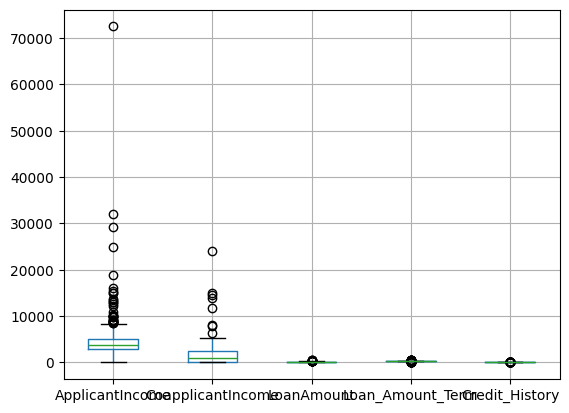

In [981]:
test_df[numerical_cols_test].boxplot()

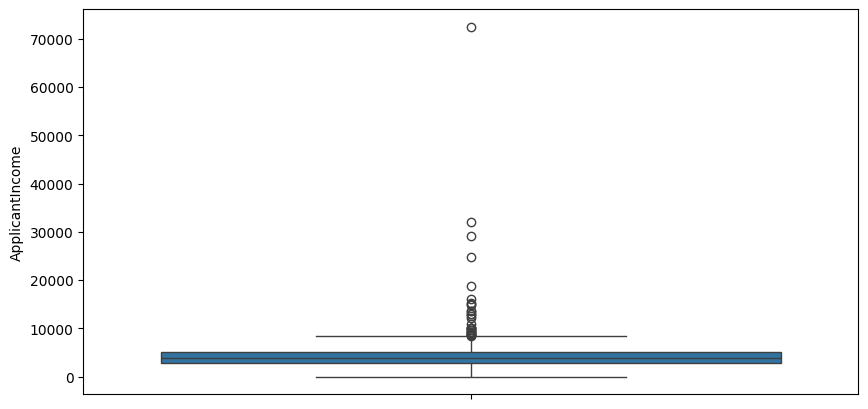

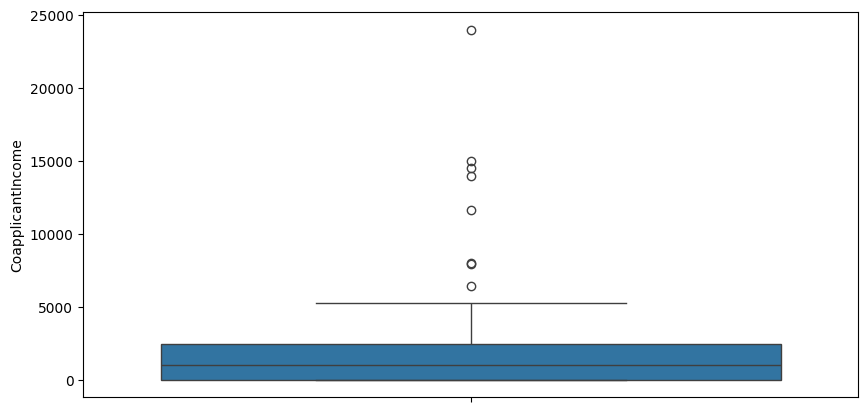

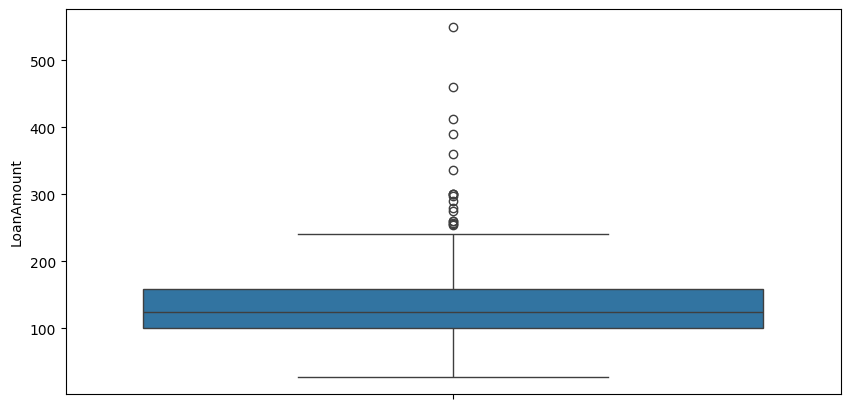

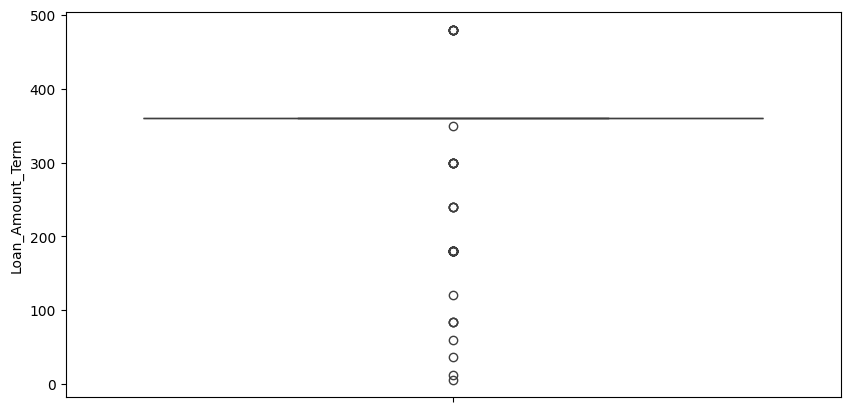

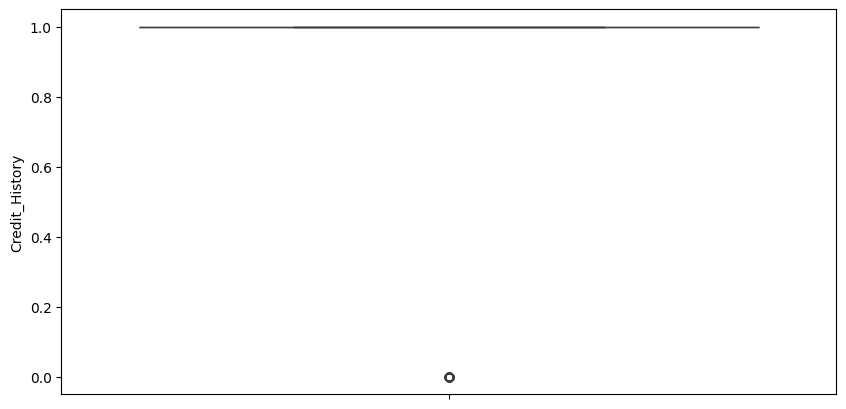

In [982]:
for i in test_df[numerical_cols_test].columns:
  plt.figure(figsize = (10,5))
  sns.boxplot(test_df[i])
  plt.show()

*Using SimpleImputer replaced by median*

In [983]:
from sklearn.impute import SimpleImputer

imputer_test_median = SimpleImputer(strategy = 'median')
test_df[numerical_cols_test] = imputer_test_median.fit_transform(test_df[numerical_cols_test])

*Using SimpleImputer replaced by mode*

In [984]:
from sklearn.impute import SimpleImputer

imputer_test_mode = SimpleImputer(strategy = 'most_frequent')
test_df[cat_cols_test] = imputer_test_mode.fit_transform(test_df[cat_cols_test])

In [985]:
test_df.isna().sum()

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


# 3. Outlier Detection and Handling

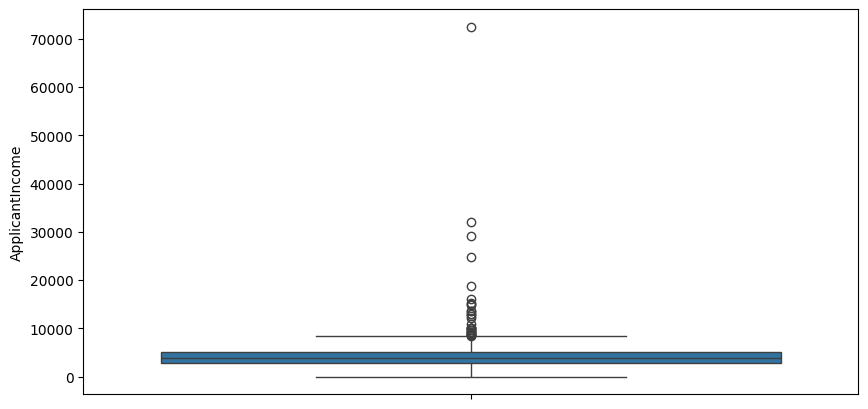

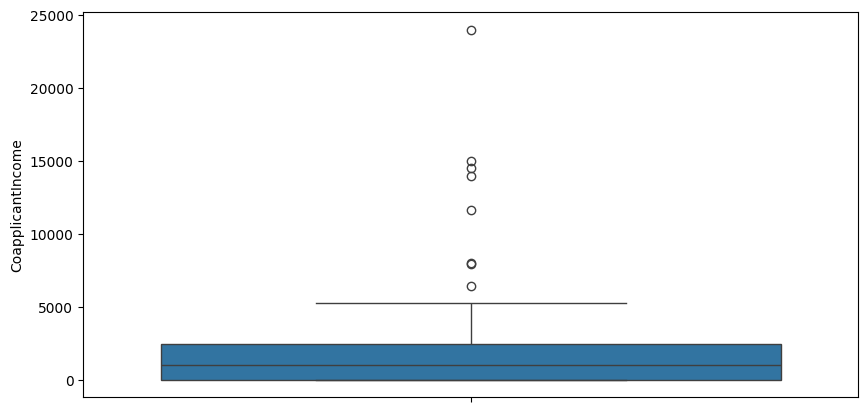

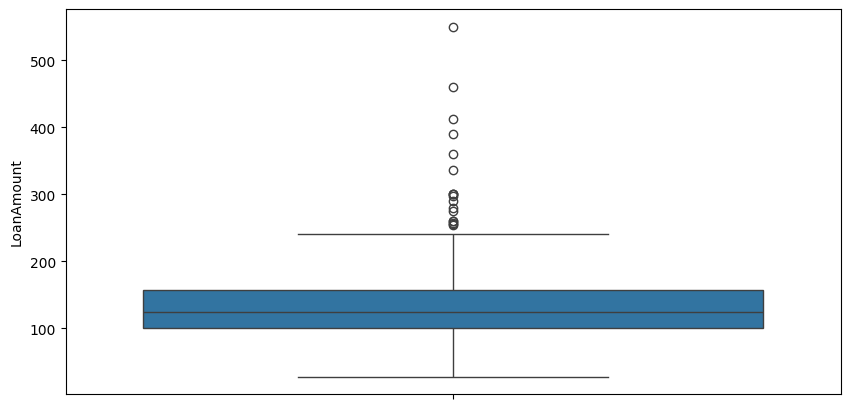

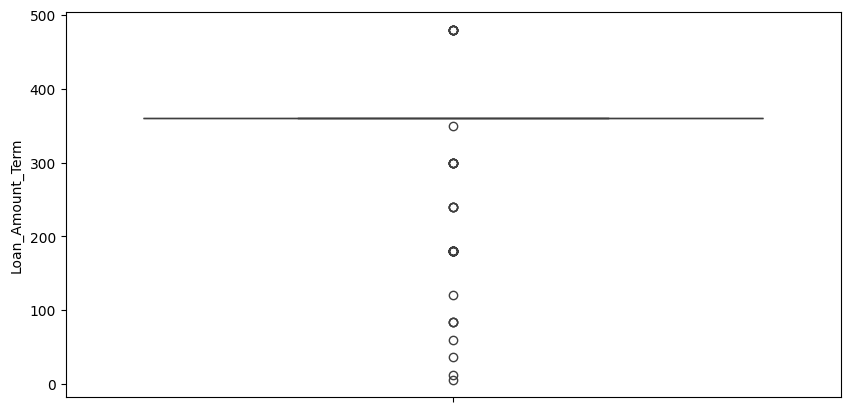

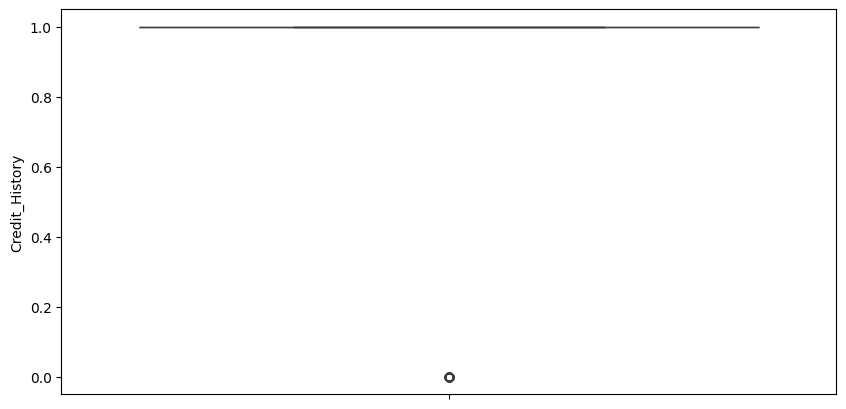

In [986]:
for i in test_df[numerical_cols_test].columns:
  plt.figure(figsize = (10,5))
  sns.boxplot(test_df[i])
  plt.show()

*Removing all the outliers from the numerical columns*

In [987]:
test_df[numerical_cols_test].columns

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')

In [988]:
def handle_outliers(test_df, columns):
  for i in columns:
    if test_df[i].dtype in ['int64', 'float64']:
      q1 = test_df[i].quantile(0.25)
      q3 = test_df[i].quantile(0.75)
      iqr = q3 - q1
      lower_bound = q1 - 1.5 * iqr
      upper_bound = q3 + 1.5 * iqr
      test_df[i] = test_df[i].clip(lower_bound,upper_bound)

  return test_df


In [989]:
test_df[numerical_cols_test] = handle_outliers(test_df[numerical_cols_test], test_df[numerical_cols_test].columns)

/tmp/ipython-input-544915912.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df[i] = test_df[i].clip(lower_bound,upper_bound)
/tmp/ipython-input-544915912.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df[i] = test_df[i].clip(lower_bound,upper_bound)
/tmp/ipython-input-544915912.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydat

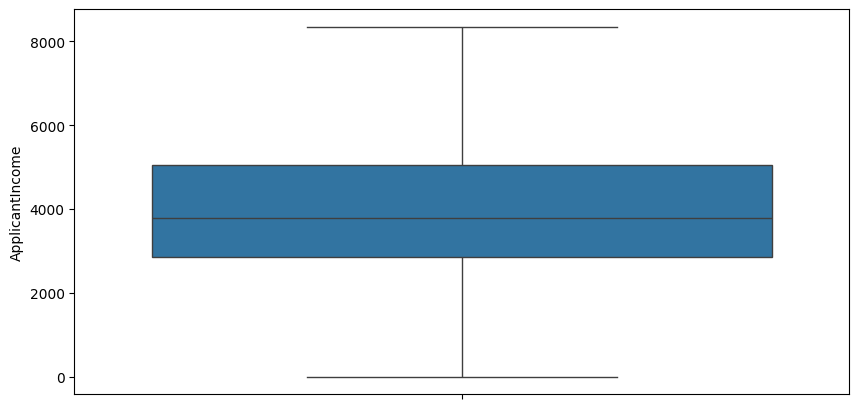

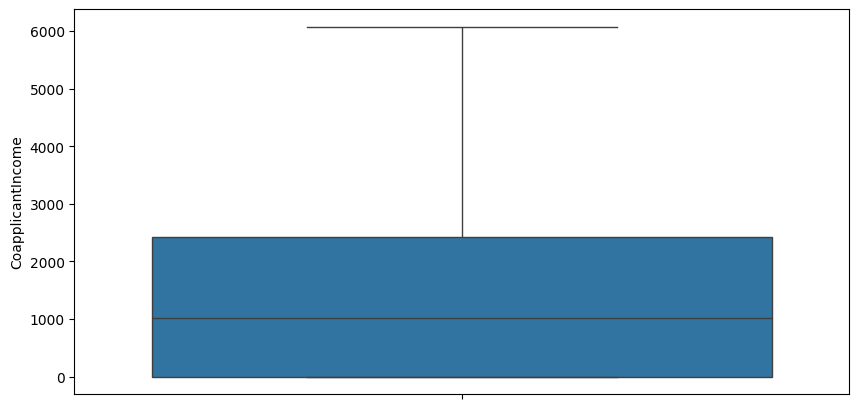

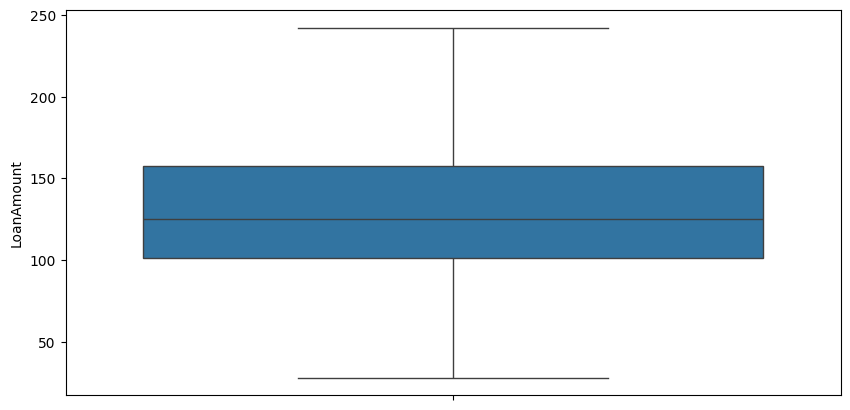

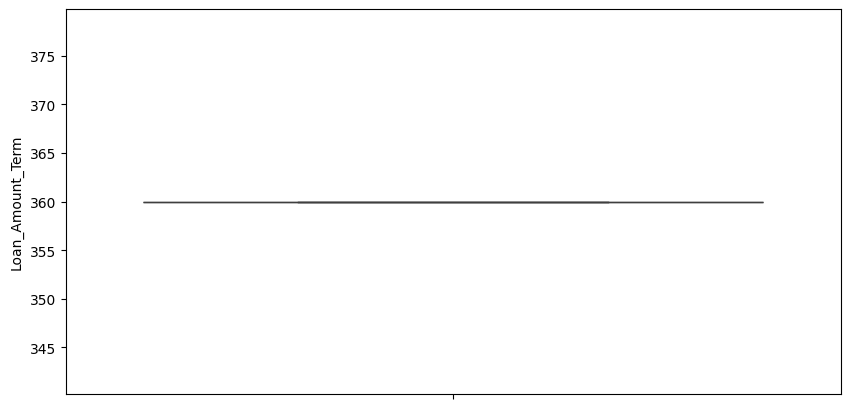

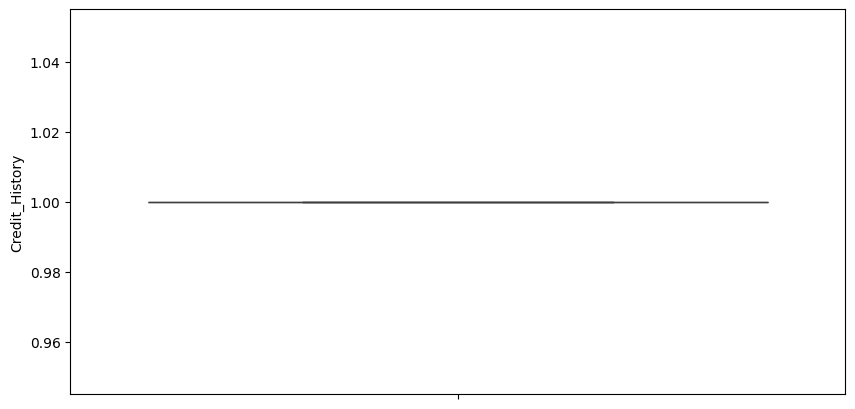

In [990]:
for i in test_df[numerical_cols_test].columns:
  plt.figure(figsize = (10,5))
  sns.boxplot(test_df[i])
  plt.show()

# 4. Feature Selection




In [991]:
test_df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,Male,Yes,0,Graduate,No,5720.0,0.0,110.0,360.0,1.0,Urban
1,Male,Yes,1,Graduate,No,3076.0,1500.0,126.0,360.0,1.0,Urban
2,Male,Yes,2,Graduate,No,5000.0,1800.0,208.0,360.0,1.0,Urban
3,Male,Yes,2,Graduate,No,2340.0,2546.0,100.0,360.0,1.0,Urban
4,Male,No,0,Not Graduate,No,3276.0,0.0,78.0,360.0,1.0,Urban


In [992]:
test_df['Loan_Amount_Term'].value_counts()

,count
Loan_Amount_Term,
360.0,367


In [993]:
test_df.drop(columns = ['Loan_Amount_Term'], inplace = True)

# 5. Handling Skewness

In [994]:
test_df.select_dtypes('number').skew()

,0
ApplicantIncome,0.791645
CoapplicantIncome,0.937228
LoanAmount,0.507530
Credit_History,0.000000


In [995]:
test_df['ApplicantIncome']= np.cbrt(test_df['ApplicantIncome'])
test_df['CoapplicantIncome'] = np.cbrt(test_df['CoapplicantIncome'])


In [996]:
test_df.select_dtypes('number').skew()

,0
ApplicantIncome,-0.912741
CoapplicantIncome,-0.064091
LoanAmount,0.507530
Credit_History,0.000000


# 6. Encoding

In [997]:
cat_cols_test = test_df.select_dtypes('object').columns
cat_cols_test

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area'],
      dtype='object')

In [998]:
test_df['Gender'].value_counts()

,count
Gender,
Male,297
Female,70


In [999]:
test_df['Married'].value_counts()

,count
Married,
Yes,233
No,134


In [1000]:
test_df['Dependents'].value_counts()

,count
Dependents,
0,210
2,59
1,58
3+,40


In [1001]:
test_df['Education'].value_counts()

,count
Education,
Graduate,283
Not Graduate,84


In [1002]:
test_df['Self_Employed'].value_counts()

,count
Self_Employed,
No,330
Yes,37


In [1003]:
test_df['Property_Area'].value_counts()

,count
Property_Area,
Urban,140
Semiurban,116
Rural,111


**Label Encoding**

In [1004]:
from sklearn.preprocessing import LabelEncoder

le_test = LabelEncoder()

test_df['Gender'] = le_test.fit_transform(test_df['Gender'])
test_df['Married'] = le_test.fit_transform(test_df['Married'])
test_df['Education'] = le_test.fit_transform(test_df['Education'])
test_df['Self_Employed'] = le_test.fit_transform(test_df['Self_Employed'])

**OneHot Encoding**

In [1005]:
test_df = pd.get_dummies(test_df, columns = ['Dependents', 'Property_Area'],dtype = int, drop_first=True)

In [1006]:
test_df.head()

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Credit_History,Dependents_1,Dependents_2,Dependents_3+,Property_Area_Semiurban,Property_Area_Urban
0,1,1,0,0,17.884028,0.000000,110.0,1.0,0,0,0,0,1
1,1,1,0,0,14.543271,11.447142,126.0,1.0,1,0,0,0,1
2,1,1,0,0,17.099759,12.164404,208.0,1.0,0,1,0,0,1
3,1,1,0,0,13.276144,13.654825,100.0,1.0,0,1,0,0,1
4,1,0,1,0,14.851875,0.000000,78.0,1.0,0,0,0,0,1


# 7. Correlataion

In [1007]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif= pd.DataFrame()
vif['VIF']=[variance_inflation_factor(test_df.values,i) for i in range(test_df.shape[1])]
vif['Columns']=test_df.columns
vif.sort_values('VIF',ascending = False)

,VIF,Columns
7,57.809108,Credit_History
4,1.669611,ApplicantIncome
5,1.475766,CoapplicantIncome
11,1.444971,Property_Area_Semiurban
12,1.444555,Property_Area_Urban
6,1.368383,LoanAmount
1,1.336210,Married
9,1.238776,Dependents_2
10,1.189839,Dependents_3+
8,1.155457,Dependents_1


# 8. Scaling and Normalization

In [1008]:
test_df.head()

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Credit_History,Dependents_1,Dependents_2,Dependents_3+,Property_Area_Semiurban,Property_Area_Urban
0,1,1,0,0,17.884028,0.000000,110.0,1.0,0,0,0,0,1
1,1,1,0,0,14.543271,11.447142,126.0,1.0,1,0,0,0,1
2,1,1,0,0,17.099759,12.164404,208.0,1.0,0,1,0,0,1
3,1,1,0,0,13.276144,13.654825,100.0,1.0,0,1,0,0,1
4,1,0,1,0,14.851875,0.000000,78.0,1.0,0,0,0,0,1


In [1009]:
scaling_cols_test = [
    'ApplicantIncome',
    'CoapplicantIncome',
    'LoanAmount'
    ]

In [1010]:
from sklearn.preprocessing import MinMaxScaler

scaler_test = MinMaxScaler()
test_df[scaling_cols_test] = scaler_test.fit_transform(test_df[scaling_cols_test])

In [1011]:
test_df.head()

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Credit_History,Dependents_1,Dependents_2,Dependents_3+,Property_Area_Semiurban,Property_Area_Urban
0,1,1,0,0,0.881388,0.000000,0.382730,1.0,0,0,0,0,1
1,1,1,0,0,0.716744,0.627314,0.457410,1.0,1,0,0,0,1
2,1,1,0,0,0.842737,0.666621,0.840140,1.0,0,1,0,0,1
3,1,1,0,0,0.654295,0.748297,0.336056,1.0,0,1,0,0,1
4,1,0,1,0,0.731953,0.000000,0.233372,1.0,0,0,0,0,1


Choosing SVC Model as it shows greater result in training dataset

In [1012]:
X_full = train_df.drop(columns='Loan_Status')
y_full = train_df['Loan_Status']

In [1013]:
final_model = SVC(kernel='rbf', C=1.0, gamma='scale')
final_model.fit(X_full, y_full)

SVC()

In [1014]:
test_df = test_df.reindex(columns=X_full.columns, fill_value=0)

In [1015]:
test_predictions= final_model.predict(test_df)
test_predictions

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [1016]:
test_predictions= le.inverse_transform(test_predictions)
test_predictions

array(['Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y

In [1017]:
submission = pd.DataFrame({
    'Loan_ID': test_ids,
    'Loan_Status': test_predictions
})

submission.to_csv('/content/drive/MyDrive/ICT DSA Python/Data/submission.csv', index=False)